Using device: cuda
Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


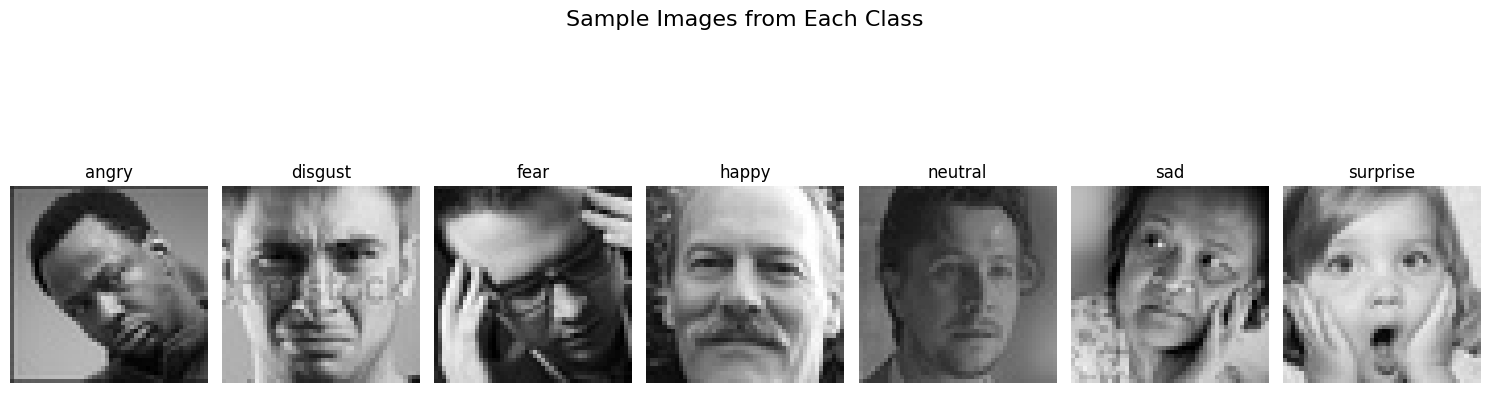

Class names (and mapping): {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Found 22967 images for training.
Found 5742 images for validation.
Found 7178 images for testing.


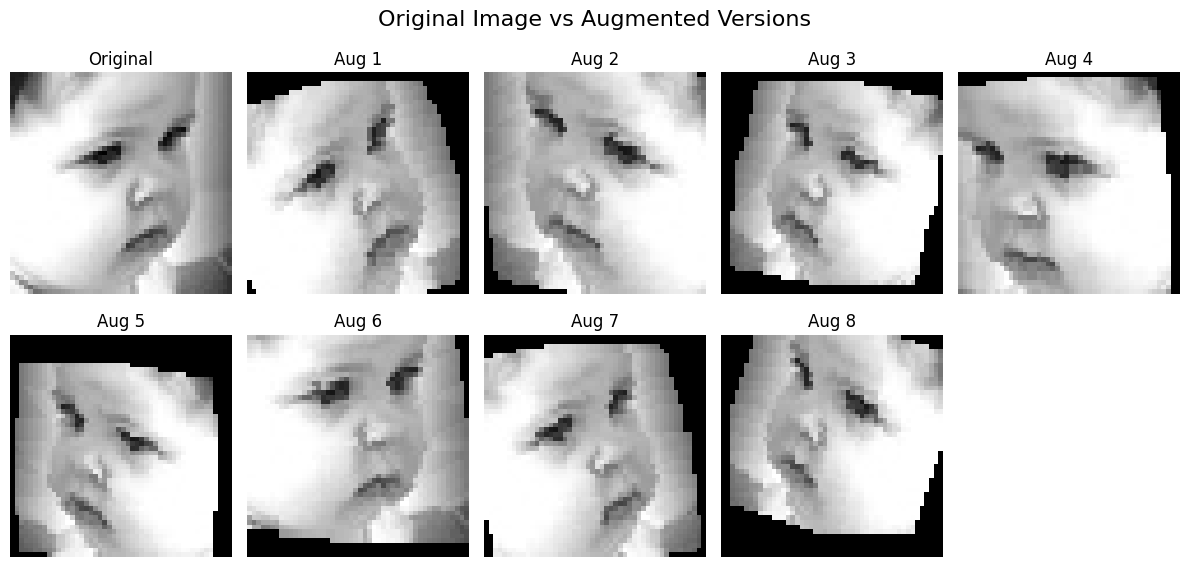

Calculated Class Weights: tensor([1.0266, 9.4011, 1.0012, 0.5684, 0.8260, 0.8491, 1.2933],
       device='cuda:0')
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]             640
       BatchNorm2d-2           [-1, 64, 48, 48]             128
            Conv2d-3           [-1, 64, 48, 48]          36,928
       BatchNorm2d-4           [-1, 64, 48, 48]             128
         MaxPool2d-5           [-1, 64, 24, 24]               0
           Dropout-6           [-1, 64, 24, 24]               0
            Conv2d-7          [-1, 128, 24, 24]          73,856
       BatchNorm2d-8          [-1, 128, 24, 24]             256
            Conv2d-9          [-1, 128, 24, 24]         147,584
      BatchNorm2d-10          [-1, 128, 24, 24]             256
        MaxPool2d-11          [-1, 128, 12, 12]               0
          Dropout-12          [-1, 128, 12, 12]     

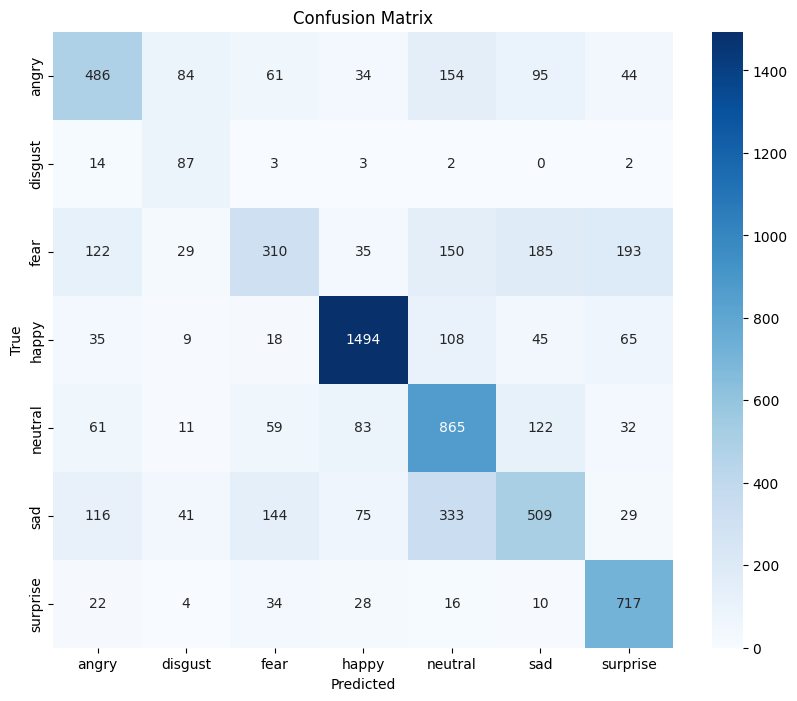

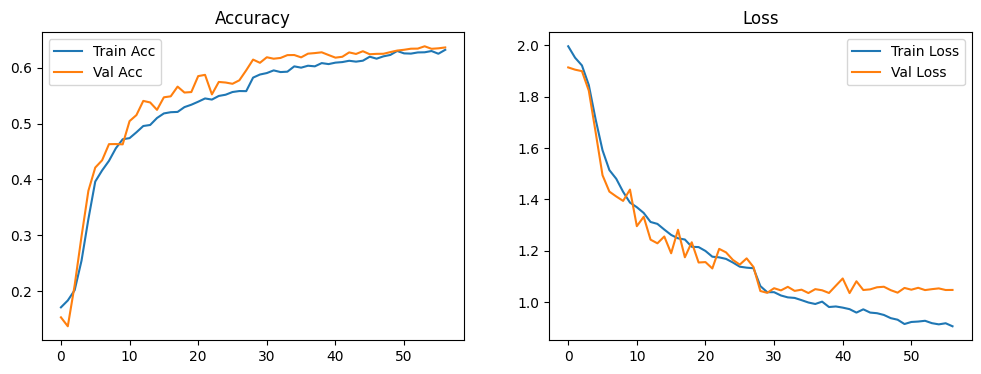

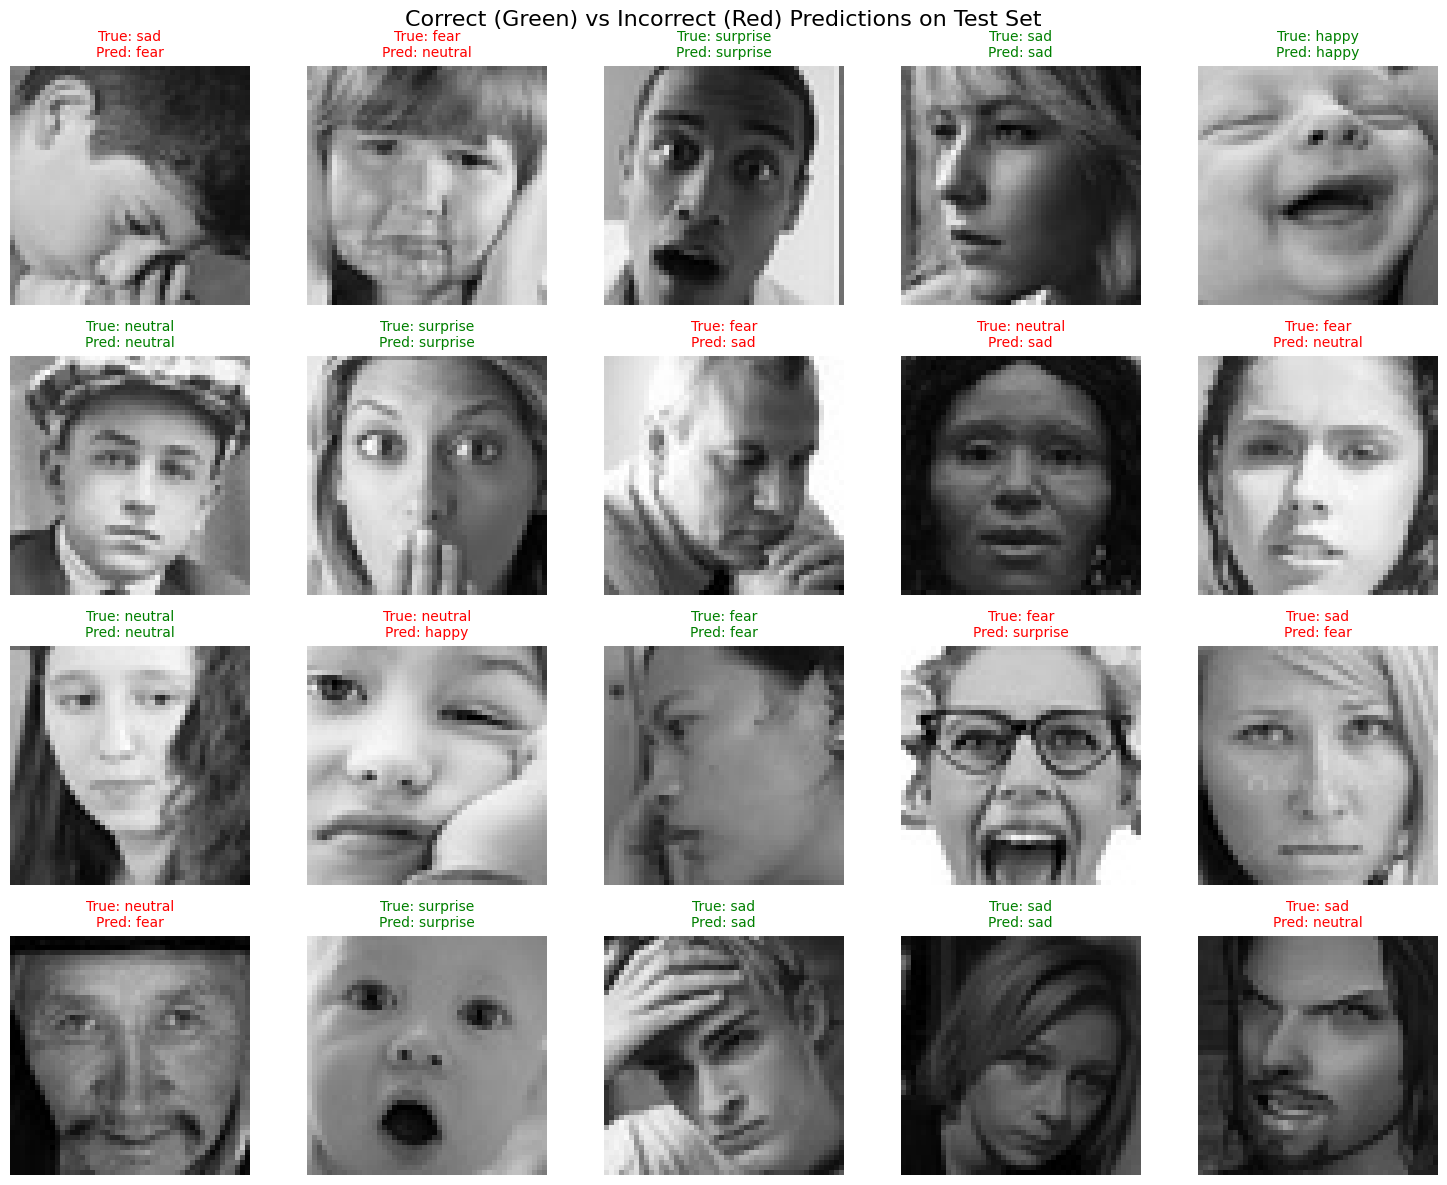


PyTorch script execution complete.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.utils import make_grid
from torchsummary import summary 

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
import cv2
import os
import copy
from PIL import Image
import time

train_path = "C:/Users/ruthr/OneDrive/Documents/face_CNN/train" 
test_path = "C:/Users/ruthr/OneDrive/Documents/face_CNN/test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 128
EPOCHS = 100 
NUM_CLASSES = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


classes = os.listdir(train_path)
print("Classes found:", classes)

plt.figure(figsize=(15, 5))
for i, emotion in enumerate(classes):
    emotion_path = os.path.join(train_path, emotion)
    random_img = random.choice(os.listdir(emotion_path))
    img_path = os.path.join(emotion_path, random_img)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Sample Images from Each Class", fontsize=16, y=1.05)
plt.show()


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),  
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

full_train_dataset = ImageFolder(train_path, transform=val_test_transform)
class_names = full_train_dataset.classes
print(f"Class names (and mapping): {full_train_dataset.class_to_idx}")

targets = full_train_dataset.targets
train_indices, val_indices = train_test_split(
    list(range(len(targets))),
    test_size=0.2,  
    stratify=targets,
    random_state=42
)


train_dataset = Subset(ImageFolder(train_path, transform=train_transform), train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

test_dataset = ImageFolder(test_path, transform=val_test_transform)

print(f"Found {len(train_dataset)} images for training.")
print(f"Found {len(val_dataset)} images for validation.")
print(f"Found {len(test_dataset)} images for testing.")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(val_loader))
img_pil = transforms.ToPILImage()(images[0]) 

plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(img_pil, cmap='gray')
plt.title("Original")
plt.axis('off')

for i in range(8):
    augmented_img = train_transform(img_pil) 
    plt.subplot(2, 5, i + 2)
    plt.imshow(augmented_img.squeeze(), cmap='gray')
    plt.title(f"Aug {i+1}")
    plt.axis('off')

plt.suptitle("Original Image vs Augmented Versions", fontsize=16)
plt.tight_layout()
plt.show()



train_labels = [targets[i] for i in train_indices]

class_weights_array = class_weight.compute_class_weight(
    "balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print("Calculated Class Weights:", class_weights_tensor)



class FER_CNNModel(nn.Module):
    def __init__(self, num_classes=7):
        super(FER_CNNModel, self).__init__()
        
        self.conv1_1 = nn.Conv2d(1, 64, kernel_size=3, padding='same')
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding='same')
        self.bn1_2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout(0.25)

        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding='same')
        self.bn2_2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout(0.25)

        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding='same')
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding='same')
        self.bn3_2 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout(0.25)

        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding='same')
        self.bn4_1 = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding='same')
        self.bn4_2 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop4 = nn.Dropout(0.25)

        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 3 * 3, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.drop_fc1 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)
        self.drop_fc2 = nn.Dropout(0.5)
        
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)
        x = self.drop1(x)

        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        x = F.relu(self.bn4_1(self.conv4_1(x)))
        x = F.relu(self.bn4_2(self.conv4_2(x)))
        x = self.pool4(x)
        x = self.drop4(x)

        x = self.flatten(x)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc1(x)
        
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.drop_fc2(x)
        
        
        x = self.fc3(x)
        return x

model = FER_CNNModel(num_classes=NUM_CLASSES).to(device)


summary(model, (1, 48, 48))


criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(model.parameters(), lr=0.001)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
)

early_stop_patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None

history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

print("Starting model training...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    
    model.train()
    running_train_loss = 0.0
    running_train_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        _, preds = torch.max(outputs, 1)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        running_train_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = running_train_corrects.double() / len(train_dataset)
    
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            
            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)
   
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_acc.item())
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc.item())
    
    scheduler.step(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} [{time.time() - epoch_start_time:.0f}s] - "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} - "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} - "
          f"LR: {optimizer.param_groups[0]['lr']:.0e}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print(f"  New best validation loss: {best_val_loss:.4f}. Saving model weights.")
    else:
        patience_counter += 1
        
    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        if best_model_weights:
            model.load_state_dict(best_model_weights)
        break

print(f"\nTraining finished in {(time.time() - start_time) / 60:.2f} minutes.")
if best_model_weights:
    model.load_state_dict(best_model_weights)
    print("Loaded best model weights for evaluation.")

model.eval()
running_test_loss = 0.0
running_test_corrects = 0

all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        _, preds = torch.max(outputs, 1)
        
        running_test_loss += loss.item() * inputs.size(0)
        running_test_corrects += torch.sum(preds == labels.data)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

test_loss = running_test_loss / len(test_dataset)
test_acc = running_test_corrects.double() / len(test_dataset)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

train_acc_plot = [acc for acc in history['train_accuracy']]
val_acc_plot = [acc for acc in history['val_accuracy']]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_accuracy'], label='Train Acc')
plt.plot(history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

test_samples = test_dataset.samples
filenames = [s[0] for s in test_samples] 
y_true = np.array(all_labels) 
y_pred = np.array(all_preds) 

correct_idx = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

n_display = 20
np.random.shuffle(correct_idx)
np.random.shuffle(incorrect_idx)

selected_correct = correct_idx[:n_display // 2]
selected_incorrect = incorrect_idx[:min(len(incorrect_idx), n_display // 2)]
selected_idx = np.concatenate([selected_correct, selected_incorrect])
np.random.shuffle(selected_idx)

plt.figure(figsize=(15, 3 * (n_display // 5 + 1)))
for i, idx in enumerate(selected_idx[:n_display]):
    img_path = filenames[idx]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE) 

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    correct = (true_label == pred_label)

    color = 'green' if correct else 'red'
    title = f"True: {true_label}\nPred: {pred_label}"

    plt.subplot(n_display // 5 + 1, 5, i + 1)
    plt.imshow(img)
    plt.title(title, color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Correct (Green) vs Incorrect (Red) Predictions on Test Set", fontsize=16)
plt.tight_layout()
plt.show()

print("\nPyTorch script execution complete.")

In [ ]:

if best_model_weights:
    model.load_state_dict(best_model_weights)
    print("Loaded best model weights for evaluation.")
else:
    print("Warning: No best model weights saved. Using the last epoch's model.")

torch.save(model.state_dict(), 'fer_model.pth')
print("Model saved to fer_model.pth")


model.eval()


Loaded best model weights for evaluation.
Model saved to fer_model.pth


FER_CNNModel(
  (conv1_1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv2_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2_1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2_2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stri